# 01 — Moteur de pricing : Black-Scholes & Greeks

**Objectif.** Construire et valider le socle analytique du projet : prix Black-Scholes-Merton (avec dividende continu $q$) et sensibilités (Greeks), codés à partir des formules fermées (`src/black_scholes.py`, `src/greeks.py`), sans librairie de pricing externe.

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2), \qquad P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$$

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

| Greek | Call | Put |
|---|---|---|
| $\Delta$ | $e^{-qT}N(d_1)$ | $e^{-qT}(N(d_1)-1)$ |
| $\Gamma$ | $\dfrac{e^{-qT}\varphi(d_1)}{S\sigma\sqrt{T}}$ | idem |
| Vega | $S e^{-qT}\varphi(d_1)\sqrt{T}$ | idem |
| $\Theta$ | $-\dfrac{S e^{-qT}\varphi(d_1)\sigma}{2\sqrt T} + qSe^{-qT}N(d_1) - rKe^{-rT}N(d_2)$ | $-\dfrac{S e^{-qT}\varphi(d_1)\sigma}{2\sqrt T} - qSe^{-qT}N(-d_1) + rKe^{-rT}N(-d_2)$ |
| $\rho$ | $KTe^{-rT}N(d_2)$ | $-KTe^{-rT}N(-d_2)$ |

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting import set_style, savefig, save_table, PALETTE

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)
%matplotlib inline
from black_scholes import black_scholes_price
from greeks import delta, gamma, vega, theta, rho, all_greeks

## 1. Validation numérique

Avant toute analyse, on vérifie le moteur : valeur de référence (Hull), parité call-put sur 10 000 jeux de paramètres aléatoires, et Greeks analytiques contre différences finies centrées.

In [2]:
bs = black_scholes_price
print(f"Call de référence (S=K=100, T=1, r=5%, σ=20%) : {bs(100, 100, 1, 0.05, 0.2, 'call'):.4f}  (Hull : 10.4506)")

rng = np.random.default_rng(42)
errs = []
for _ in range(10_000):
    S, K = rng.uniform(10, 500, 2); T = rng.uniform(0.01, 5); r = rng.uniform(0, 0.1)
    sig = rng.uniform(0.01, 1.5); q = rng.uniform(0, 0.05)
    lhs = bs(S, K, T, r, sig, "call", q) - bs(S, K, T, r, sig, "put", q)
    errs.append(abs(lhs - (S * np.exp(-q * T) - K * np.exp(-r * T))))
print(f"Parité call-put — erreur max sur 10 000 tirages : {max(errs):.2e}")

Call de référence (S=K=100, T=1, r=5%, σ=20%) : 10.4506  (Hull : 10.4506)


Parité call-put — erreur max sur 10 000 tirages : 1.14e-13


In [3]:
# Greeks analytiques vs différences finies (call, S=100, K=105, T=0.5, r=3%, σ=25%, q=1%)
S, K, T, r, sig, q = 100, 105, 0.5, 0.03, 0.25, 0.01
h = 1e-3
fd = {
    "delta": (bs(S+h, K, T, r, sig, "call", q) - bs(S-h, K, T, r, sig, "call", q)) / (2*h),
    "gamma": (bs(S+h, K, T, r, sig, "call", q) - 2*bs(S, K, T, r, sig, "call", q) + bs(S-h, K, T, r, sig, "call", q)) / h**2,
    "vega":  (bs(S, K, T, r, sig+h, "call", q) - bs(S, K, T, r, sig-h, "call", q)) / (2*h),
    "theta": -(bs(S, K, T+h, r, sig, "call", q) - bs(S, K, T-h, r, sig, "call", q)) / (2*h),
    "rho":   (bs(S, K, T, r+h, sig, "call", q) - bs(S, K, T, r-h, sig, "call", q)) / (2*h),
}
ana = all_greeks(S, K, T, r, sig, "call", q)
greeks_check = pd.DataFrame({"Analytique": ana, "Diff. finies": fd})
greeks_check["Écart absolu"] = (greeks_check["Analytique"] - greeks_check["Diff. finies"]).abs()
save_table(greeks_check.reset_index(names="Greek"), "01_greeks_validation", floatfmt=".2e")
greeks_check.style.format("{:.3e}")

,Analytique,Diff. finies,Écart absolu
delta,4.456e-01,4.456e-01,6.983e-12
gamma,2.226e-02,2.226e-02,1.724e-09
vega,2.783e+01,2.783e+01,1.118e-05
theta,-7.688e+00,-7.688e+00,2.930e-06
rho,1.961e+01,1.961e+01,3.830e-07


Les écarts sont de l'ordre de $10^{-7}$ à $10^{-9}$, soit l'erreur de troncature des différences finies : les formules analytiques sont correctes. Ces vérifications sont automatisées dans `tests/test_pricing.py` et `tests/test_greeks.py` (`pytest`).

## 2. Prix des options en fonction du sous-jacent

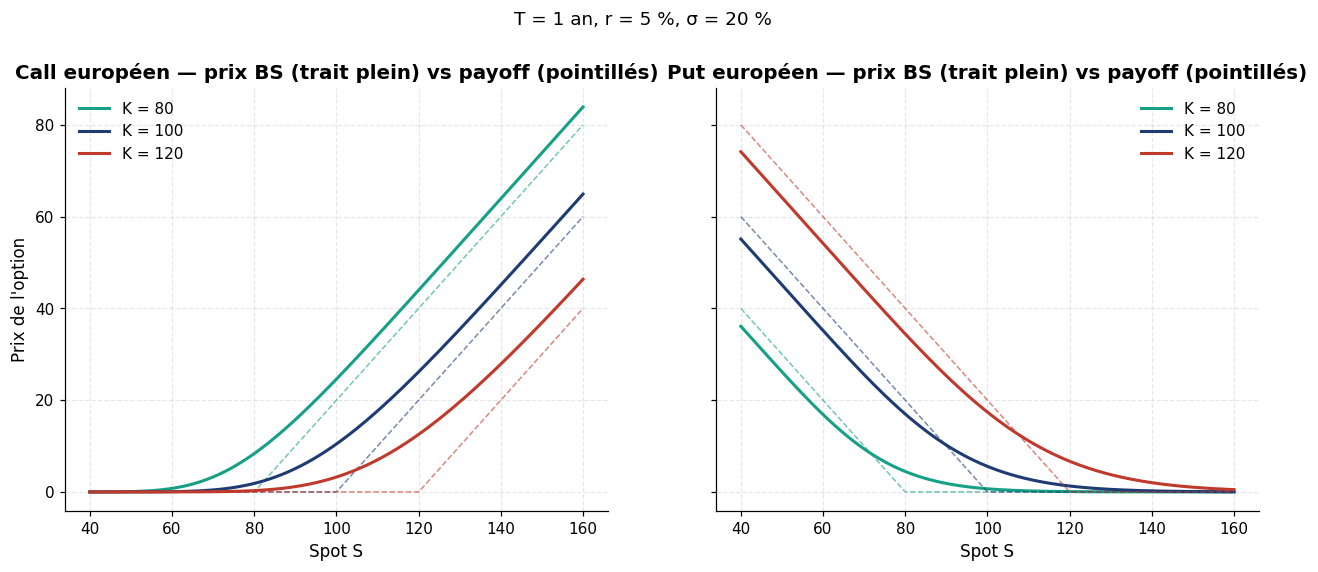

In [4]:
S_grid = np.linspace(40, 160, 400)
T, r, sig = 1.0, 0.05, 0.20
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, typ in zip(axes, ["call", "put"]):
    for K, c in zip([80, 100, 120], [PALETTE["teal"], PALETTE["navy"], PALETTE["crimson"]]):
        ax.plot(S_grid, [bs(s, K, T, r, sig, typ) for s in S_grid], color=c, lw=2, label=f"K = {K}")
        payoff = np.maximum(S_grid - K, 0) if typ == "call" else np.maximum(K - S_grid, 0)
        ax.plot(S_grid, payoff, color=c, lw=1, ls="--", alpha=0.6)
    ax.set_title(f"{typ.capitalize()} européen — prix BS (trait plein) vs payoff (pointillés)")
    ax.set_xlabel("Spot S"); ax.legend()
axes[0].set_ylabel("Prix de l'option")
fig.suptitle("T = 1 an, r = 5 %, σ = 20 %", y=1.02)
savefig(fig, "01_price_vs_spot.png"); plt.show()

L'écart entre la courbe et le payoff est la **valeur temps** : maximale à la monnaie, elle disparaît dans les ailes. Pour un call deep ITM, le prix tend vers $S e^{-qT} - Ke^{-rT}$ (le put vers 0).

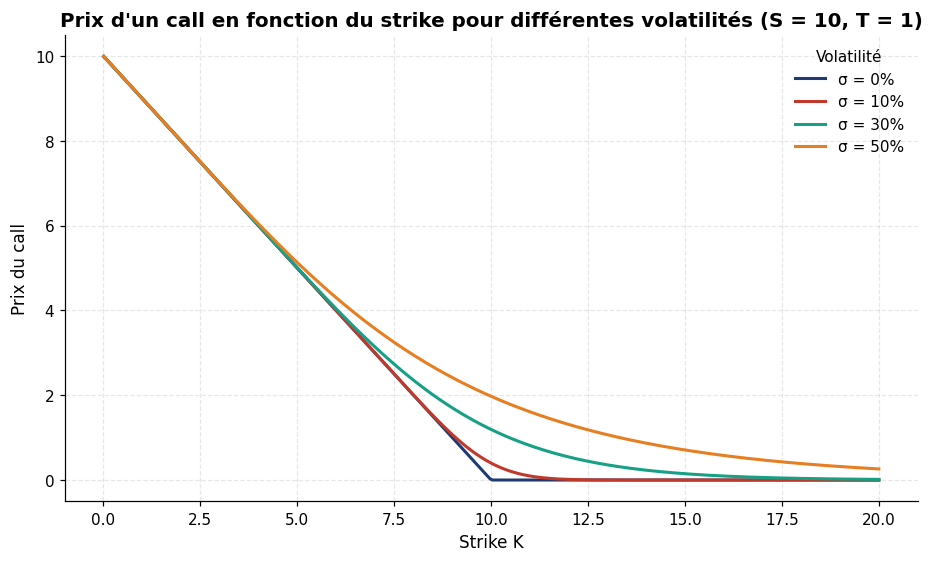

In [5]:
K_grid = np.linspace(0.01, 20, 300)
fig, ax = plt.subplots(figsize=(10, 5.5))
for sig_i in [0.0001, 0.10, 0.30, 0.50]:
    ax.plot(K_grid, [bs(10, k, 1, 0.0, sig_i, "call") for k in K_grid], lw=2, label=f"σ = {sig_i:.0%}")
ax.set_title("Prix d'un call en fonction du strike pour différentes volatilités (S = 10, T = 1)")
ax.set_xlabel("Strike K"); ax.set_ylabel("Prix du call"); ax.legend(title="Volatilité")
savefig(fig, "01_price_vs_strike_vol.png"); plt.show()

## 3. Les Greeks en fonction du spot, pour plusieurs maturités

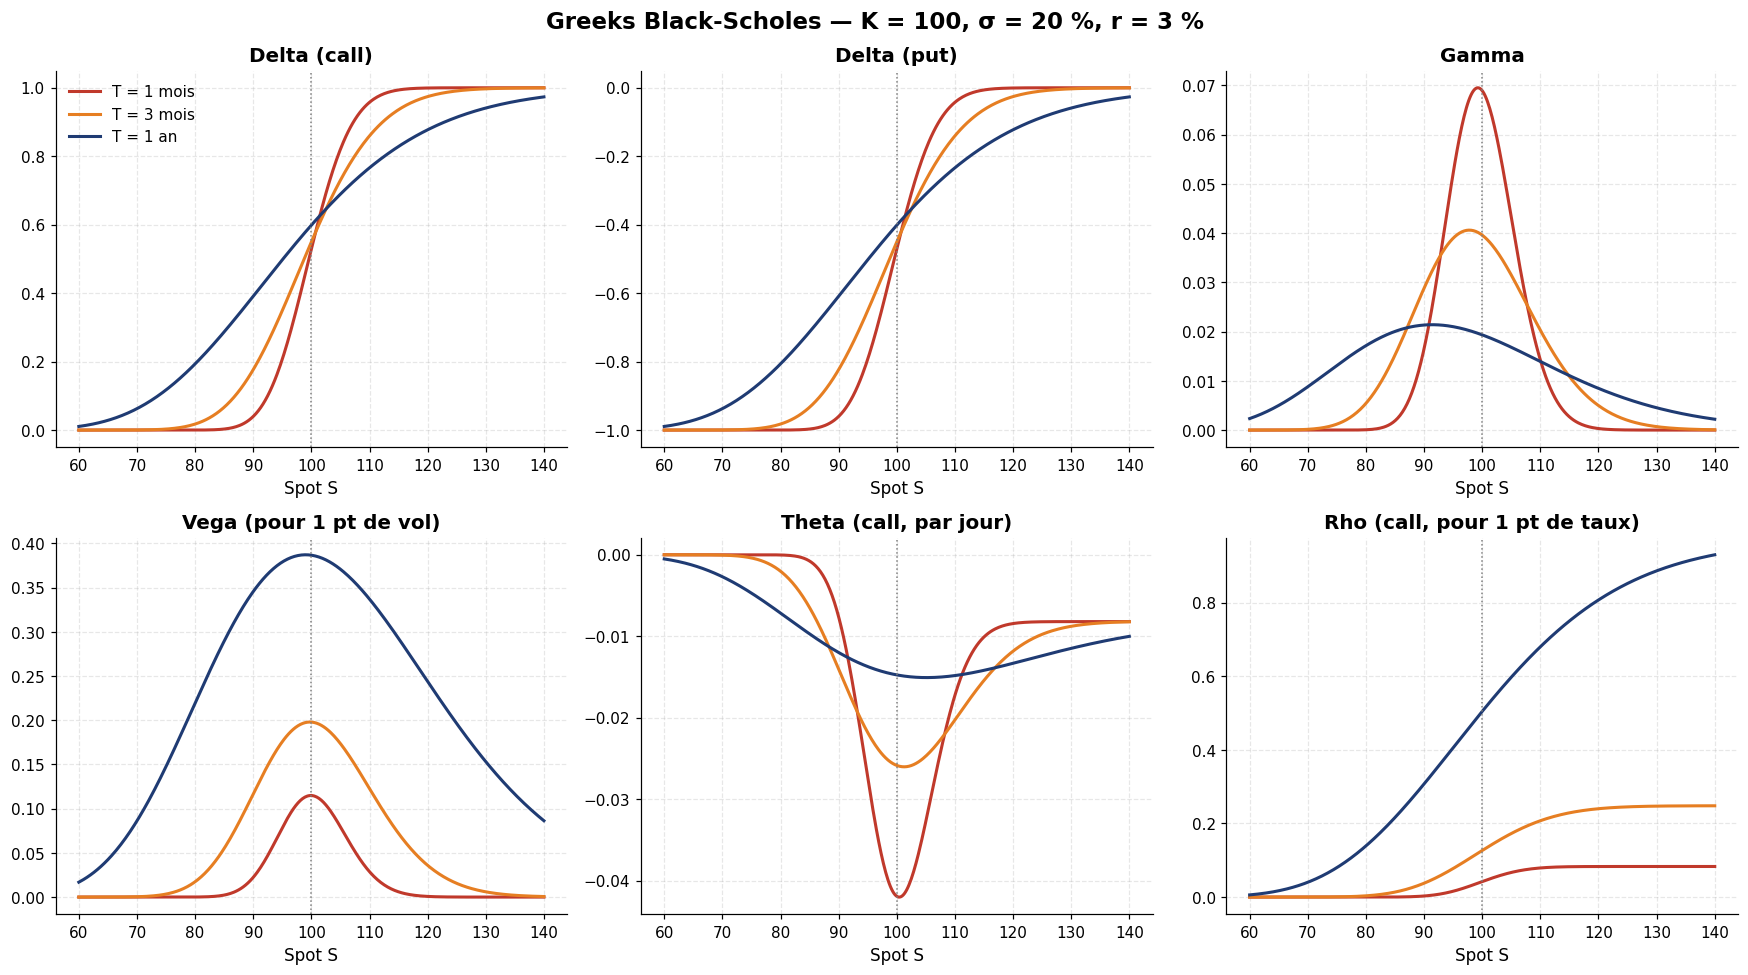

In [6]:
S_grid = np.linspace(60, 140, 400)
K, r, sig, q = 100, 0.03, 0.20, 0.0
mats = {"T = 1 mois": 1/12, "T = 3 mois": 0.25, "T = 1 an": 1.0}
funcs = {"Delta (call)": lambda s, t: delta(s, K, t, r, sig, "call", q),
         "Delta (put)": lambda s, t: delta(s, K, t, r, sig, "put", q),
         "Gamma": lambda s, t: gamma(s, K, t, r, sig, "call", q),
         "Vega (pour 1 pt de vol)": lambda s, t: vega(s, K, t, r, sig, "call", q) / 100,
         "Theta (call, par jour)": lambda s, t: theta(s, K, t, r, sig, "call", q) / 365,
         "Rho (call, pour 1 pt de taux)": lambda s, t: rho(s, K, t, r, sig, "call", q) / 100}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, f) in zip(axes.ravel(), funcs.items()):
    for (lab, t), c in zip(mats.items(), [PALETTE["crimson"], PALETTE["orange"], PALETTE["navy"]]):
        ax.plot(S_grid, f(S_grid, t), lw=2, color=c, label=lab)
    ax.axvline(K, color="grey", ls=":", lw=1)
    ax.set_title(name); ax.set_xlabel("Spot S")
axes[0, 0].legend()
fig.suptitle("Greeks Black-Scholes — K = 100, σ = 20 %, r = 3 %", fontsize=15, fontweight="bold")
fig.tight_layout(); savefig(fig, "01_greeks_vs_spot.png"); plt.show()

**Lecture.**
- **Delta** : fonction de répartition « lissée » ; plus la maturité est courte, plus la transition autour du strike est brutale (le delta devient une marche à l'échéance).
- **Gamma** : concentré autour de l'ATM et **explose quand $T \to 0$** ($\Gamma \propto 1/\sqrt{T}$ à la monnaie). C'est précisément ce qui rend le delta-hedging difficile sur les options courtes ATM (notebook 06).
- **Vega** : maximal ATM et croissant avec $\sqrt{T}$ : les options longues sont les instruments naturels pour prendre une position de volatilité.
- **Theta** : négatif pour un call acheté, très négatif ATM court terme — c'est la contrepartie du gamma (relation $\Theta + \tfrac12\sigma^2S^2\Gamma + (r-q)S\Delta - rV = 0$).

In [7]:
# Vérification de l'équation de Black-Scholes : Θ + ½σ²S²Γ + (r−q)SΔ − rV = 0
S, K, T, r, sig, q = 104, 100, 0.4, 0.03, 0.22, 0.01
for typ in ["call", "put"]:
    g = all_greeks(S, K, T, r, sig, typ, q)
    pde = g["theta"] + 0.5 * sig**2 * S**2 * g["gamma"] + (r - q) * S * g["delta"] - r * bs(S, K, T, r, sig, typ, q)
    print(f"{typ:>4} : résidu de l'EDP de Black-Scholes = {pde:.2e}")

call : résidu de l'EDP de Black-Scholes = 2.41e-15
 put : résidu de l'EDP de Black-Scholes = 1.96e-15


## 4. Vega en fonction de la volatilité et Delta en fonction du temps

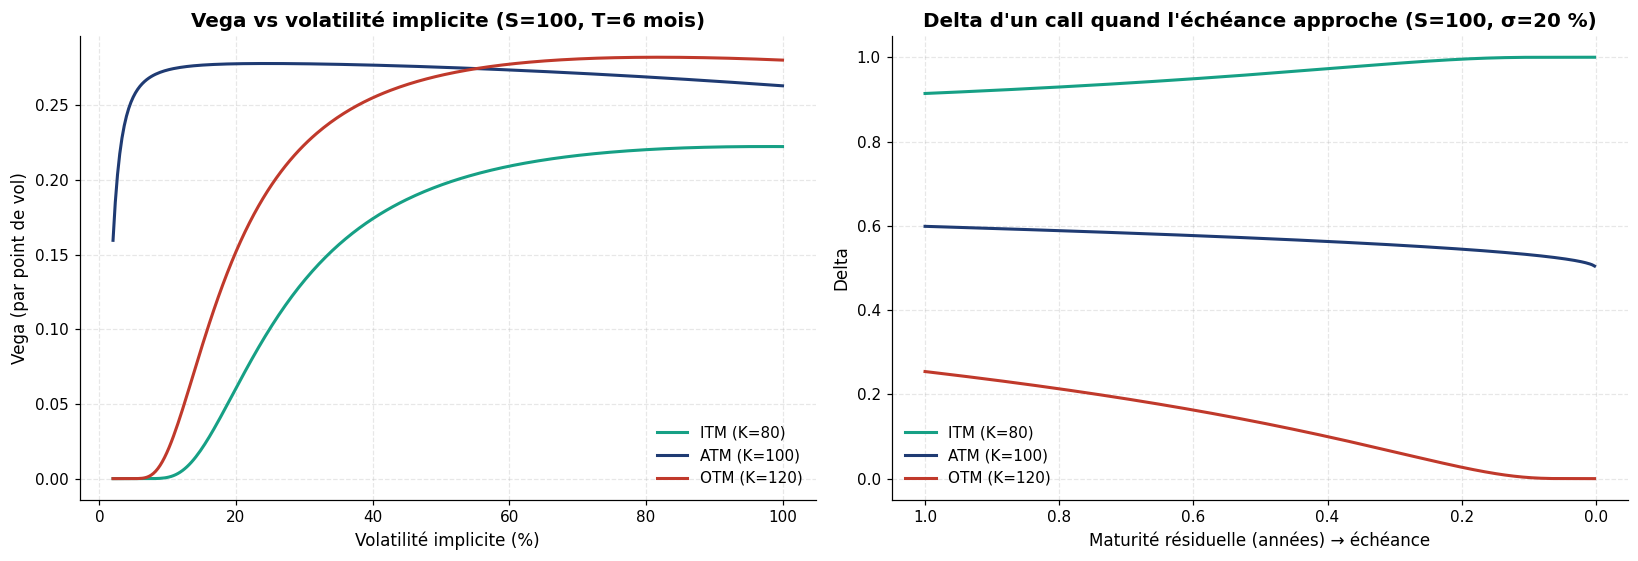

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sig_grid = np.linspace(0.02, 1.0, 300)
for K, lab, c in [(80, "ITM (K=80)", PALETTE["teal"]), (100, "ATM (K=100)", PALETTE["navy"]), (120, "OTM (K=120)", PALETTE["crimson"])]:
    axes[0].plot(sig_grid * 100, vega(100, K, 0.5, 0.03, sig_grid) / 100, lw=2, color=c, label=lab)
axes[0].set_title("Vega vs volatilité implicite (S=100, T=6 mois)")
axes[0].set_xlabel("Volatilité implicite (%)"); axes[0].set_ylabel("Vega (par point de vol)"); axes[0].legend()

tau = np.linspace(0.002, 1.0, 300)
for K, lab, c in [(80, "ITM (K=80)", PALETTE["teal"]), (100, "ATM (K=100)", PALETTE["navy"]), (120, "OTM (K=120)", PALETTE["crimson"])]:
    axes[1].plot(tau, delta(100, K, tau, 0.03, 0.2, "call"), lw=2, color=c, label=lab)
axes[1].invert_xaxis()
axes[1].set_title("Delta d'un call quand l'échéance approche (S=100, σ=20 %)")
axes[1].set_xlabel("Maturité résiduelle (années) → échéance"); axes[1].set_ylabel("Delta"); axes[1].legend()
fig.tight_layout(); savefig(fig, "01_vega_vs_vol_delta_vs_time.png"); plt.show()

- La vega ATM est quasi linéaire en $\sigma$ (le prix ATM est ≈ $0.4\,S\sigma\sqrt T$), alors que la vega des options OTM est très **convexe** en vol (« volga ») : une option OTM a peu de vega quand la vol est basse, mais en gagne énormément quand la vol monte — c'est l'une des raisons pour lesquelles le marché paie une prime sur les ailes (smile).
- Quand l'échéance approche, le delta converge vers 1 (ITM), 0 (OTM) ; le delta ATM reste autour de 0.5 : c'est le cas le plus instable pour le hedger (on retrouve la figure 17.4 de Hull).

## Conclusion
Le moteur analytique est validé (parité, EDP, différences finies) et constitue la référence pour la suite : benchmark du Monte Carlo (02), inversion de l'IV (03), et moteur de couverture (06).